In [54]:
ls

all_data_decomposed_100ms_1core.csv
all_data_decomposed_100ms_apiserver_pinned.csv
all_data_decomposed_100ms.csv
all_data_decomposed_10ms_1core.csv
all_data_decomposed_10ms_apiserver_pinned.csv
all_data_decomposed_10ms.csv
all_data_decomposed_1s_1core.csv
all_data_decomposed_1s_apiserver_pinned.csv
all_data_decomposed_1s.csv
all_data_decomposed_200ms_1core.csv
all_data_decomposed_200ms_apiserver_pinned.csv
all_data_decomposed_200ms.csv
all_data_decomposed_50ms_1core.csv
all_data_decomposed_50ms_apiserver_pinned.csv
all_data_decomposed_50ms.csv
coldrate_analysis.pdf
coldrate_analysis.png
cold_rate.csv
p99_breakdown_percent.pdf
p99_breakdown_percent.png
Untitled4.ipynb
Untitled.ipynb


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

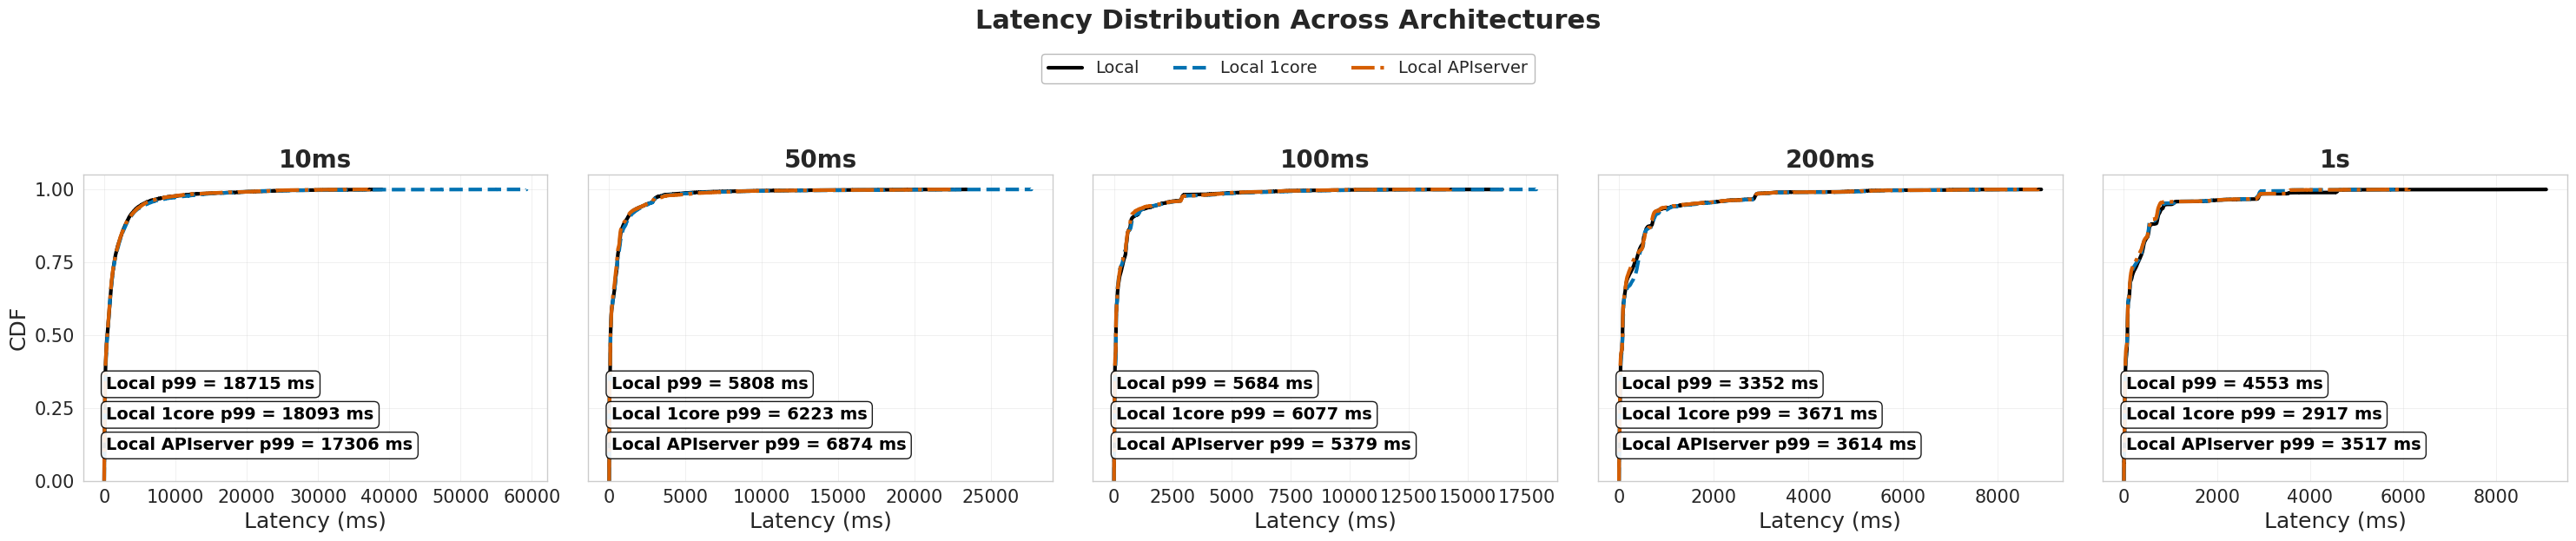

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os
import textwrap

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": ["Times New Roman", "DejaVu Serif"],

    # 🔥 BIGGER GLOBAL FONT
    "font.size": 18,

    "axes.titlesize": 20,
    "axes.labelsize": 18,

    "xtick.labelsize": 15,
    "ytick.labelsize": 15,

    "legend.fontsize": 14,

    "lines.linewidth": 3.0,

    "axes.spines.top": False,
    "axes.spines.right": False,
})

sns.set_style("whitegrid")

# ─── COLORS ───────────────────────────────────────────────────────────
COLORS     = ["#000000", "#0072B2", "#D55E00"]
LINESTYLES = ["-", "--", "-."]
LABELS     = ["Local", "Local 1core", "Local APIserver"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"all_data_decomposed_{d}.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"all_data_decomposed_{d}_1core.csv") for d in DELAYS
    },
    "Local APIserver": {
        d: os.path.join(DATA_DIR, f"all_data_decomposed_{d}_apiserver_pinned.csv") for d in DELAYS
    },
}

MODES = ["Local", "Local 1core", "Local APIserver"]

# ─── LOAD ─────────────────────────────────────────────────────────────
def load_series(path):
    if not os.path.exists(path):
        return None
    return pd.read_csv(path)["latency_ms"].dropna()

# ─── AVAILABLE DELAYS ────────────────────────────────────────────────
available_delays = [
    d for d in DELAYS
    if any(os.path.exists(FILES[m][d]) for m in MODES)
]

# ─── FIGURE ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1,
    len(available_delays),
    figsize=(6 * len(available_delays), 6),
    sharey=True
)

if len(available_delays) == 1:
    axes = [axes]

# ─── PLOT ─────────────────────────────────────────────────────────────
for c, delay in enumerate(available_delays):
    ax = axes[c]

    ax.set_title("\n".join(textwrap.wrap(delay, 6)), fontweight="bold", fontsize=20)

    for i, mode in enumerate(MODES):
        path = FILES[mode][delay]
        data = load_series(path)

        if data is None or len(data) == 0:
            continue

        p99 = data.quantile(0.99)

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            label=LABELS[i]
        )

        # ─── p99 TEXT (🔥 BIGGER + MORE VISIBLE) ─────────────
        ax.text(
            0.05,
            0.30 - i * 0.10,
            f"{LABELS[i]} p99 = {p99:.0f} ms",
            transform=ax.transAxes,
            fontsize=14,          # 🔥 bigger
            fontweight="bold",
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="black",
                alpha=0.9
            )
        )

    # ─── AXES ───────────────────────────────────────
    ax.set_xlabel("Latency (ms)", fontsize=18)

    if c == 0:
        ax.set_ylabel("CDF", fontsize=18)

    ax.set_ylim(0, 1.05)

    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.2f}")

# ─── LEGEND ─────────────────────────────────────────
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=True,
    fontsize=14
)

# ─── TITLE ───────────────────────────────────────────
fig.suptitle(
    "Latency Distribution Across Architectures",
    fontsize=22,
    fontweight="bold",
    y=1.05
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

# ─── EXPORT ──────────────────────────────────────────
plt.savefig("ecdf_final_big_fonts.pdf", dpi=300, bbox_inches="tight")
plt.savefig("ecdf_final_big_fonts.png", dpi=300, bbox_inches="tight")

plt.show()

Delays (warm): ['10ms', '50ms', '100ms', '200ms', '1s']
✓ fig_tail_warm_abs.pdf/.png


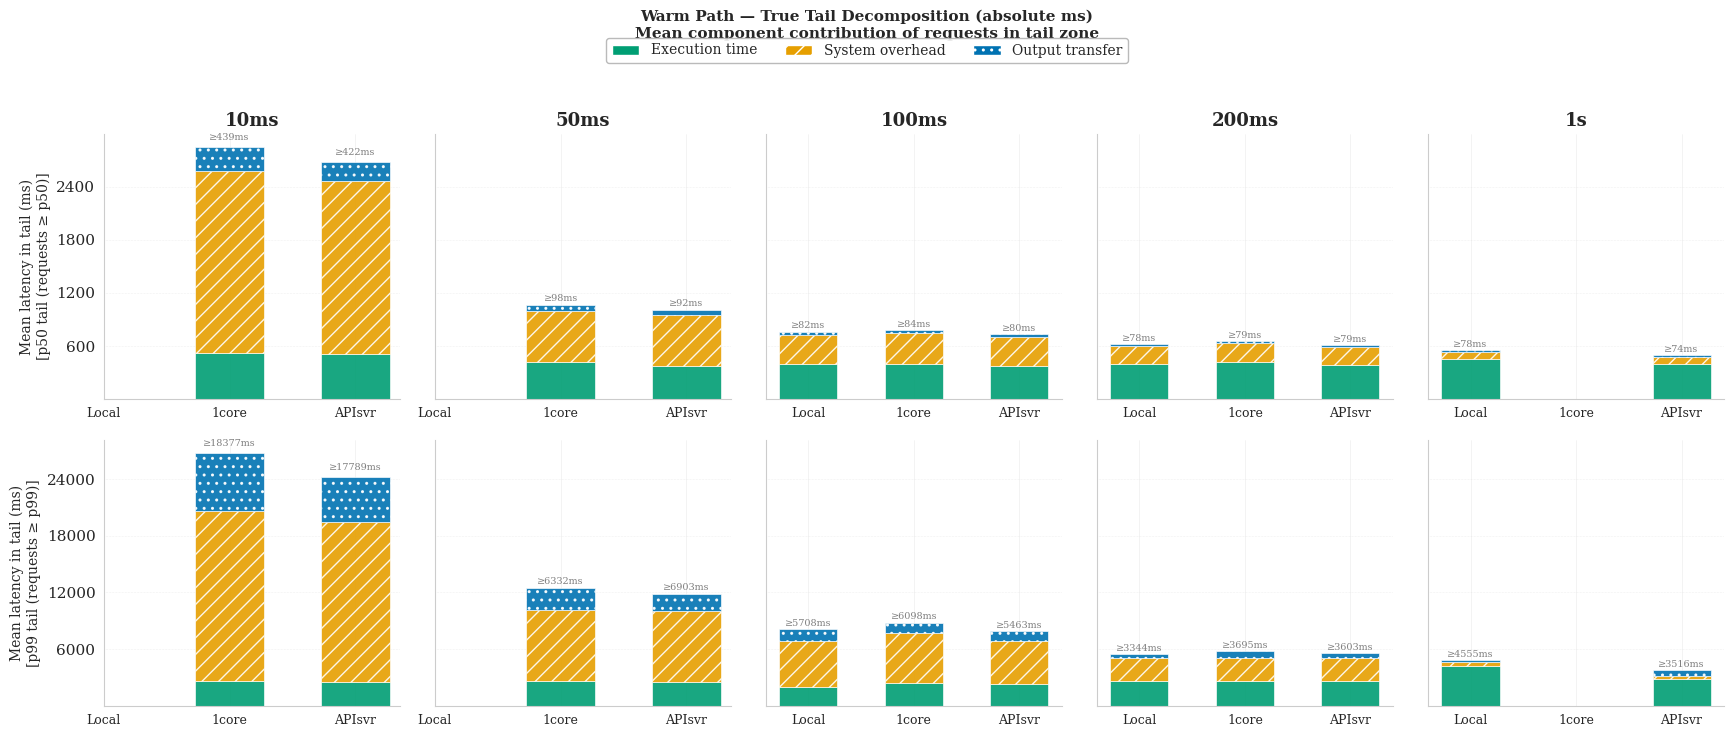

In [42]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.patches import Patch

plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 11, "legend.fontsize": 10,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

DELAYS   = ["10ms", "50ms", "100ms", "200ms", "1s"]
ARCHS    = ["Local", "Local 1core", "Local APIserver"]
DATA_DIR = "."
FILES = {
    "Local":           {d: f"all_data_decomposed_{d}.csv"                  for d in DELAYS},
    "Local 1core":     {d: f"all_data_decomposed_{d}_1core.csv"            for d in DELAYS},
    "Local APIserver": {d: f"all_data_decomposed_{d}_apiserver_pinned.csv" for d in DELAYS},
}
STACK_COLS    = ["execution_time_ms", "system_overhead_ms", "output_transfer_ms"]
STACK_LABELS  = ["Execution time", "System overhead", "Output transfer"]
STACK_COLORS  = ["#009E73", "#E69F00", "#0072B2"]
STACK_HATCHES = ["", "//", ".."]
REQ_TYPE = "warm"

def load(arch, delay):
    path = os.path.join(DATA_DIR, FILES[arch][delay])
    if not os.path.exists(path): return None
    df = pd.read_csv(path)
    df = df[(df["status"] == 200) & (df["type"] == REQ_TYPE)].copy()
    for col in STACK_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df if len(df) > 0 else None

def tail_decomp(df, pctile):
    thresh = np.percentile(df["latency_ms"].dropna(), pctile)
    tail   = df[df["latency_ms"] >= thresh]
    result = {col: tail[col].mean() if len(tail) > 0 else 0 for col in STACK_COLS}
    result["n_tail"] = len(tail)
    result["thresh"] = thresh
    return result

available = [d for d in DELAYS if any(load(a, d) is not None for a in ARCHS)]
print(f"Delays ({REQ_TYPE}): {available}")

n = len(available)
fig, axes = plt.subplots(2, n, figsize=(3.5 * n, 7), sharey='row')
if n == 1: axes = axes.reshape(2, 1)

PCTILES    = [50, 99]
ROW_TITLES = ["p50 tail (requests ≥ p50)", "p99 tail (requests ≥ p99)"]
bar_w = 0.55
x = np.arange(len(ARCHS))

for row, pctile in enumerate(PCTILES):
    for c, delay in enumerate(available):
        ax = axes[row][c]
        for ai, arch in enumerate(ARCHS):
            df = load(arch, delay)
            if df is None: continue
            decomp = tail_decomp(df, pctile)
            bottom = 0
            for col, color, hatch in zip(STACK_COLS, STACK_COLORS, STACK_HATCHES):
                val = decomp.get(col, 0)
                ax.bar(ai, val, bottom=bottom, width=bar_w,
                       color=color, hatch=hatch,
                       edgecolor="white", linewidth=0.5, alpha=0.9)
                bottom += val
            ax.text(ai, bottom + bottom * 0.02,
                    f"≥{decomp['thresh']:.0f}ms",
                    ha='center', va='bottom', fontsize=7, color='gray')

        if row == 0: ax.set_title(delay, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(["Local", "1core", "APIsvr"], fontsize=9)
        if c == 0:
            ax.set_ylabel(f"Mean latency in tail (ms)\n[{ROW_TITLES[row]}]",
                          fontsize=10)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
        ax.grid(True, axis='y', linestyle=':', linewidth=0.4, color='0.75')
        ax.tick_params(direction='out', length=3, width=0.6, pad=3)

handles = [Patch(facecolor=STACK_COLORS[i], hatch=STACK_HATCHES[i],
                 label=STACK_LABELS[i], edgecolor='white') for i in range(3)]
fig.legend(handles=handles, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.02), fontsize=10, framealpha=0.9)
fig.suptitle("Warm Path — True Tail Decomposition (absolute ms)\n"
             "Mean component contribution of requests in tail zone",
             fontsize=11, fontweight='bold', y=1.05)
plt.tight_layout()
fig.savefig("fig_tail_warm_abs.pdf", dpi=300, bbox_inches="tight")
fig.savefig("fig_tail_warm_abs.png", dpi=300, bbox_inches="tight")
print("✓ fig_tail_warm_abs.pdf/.png")


Delays: ['10ms', '50ms', '100ms', '200ms', '1s']
✓ Saved tail_decomposition_p99.pdf/png


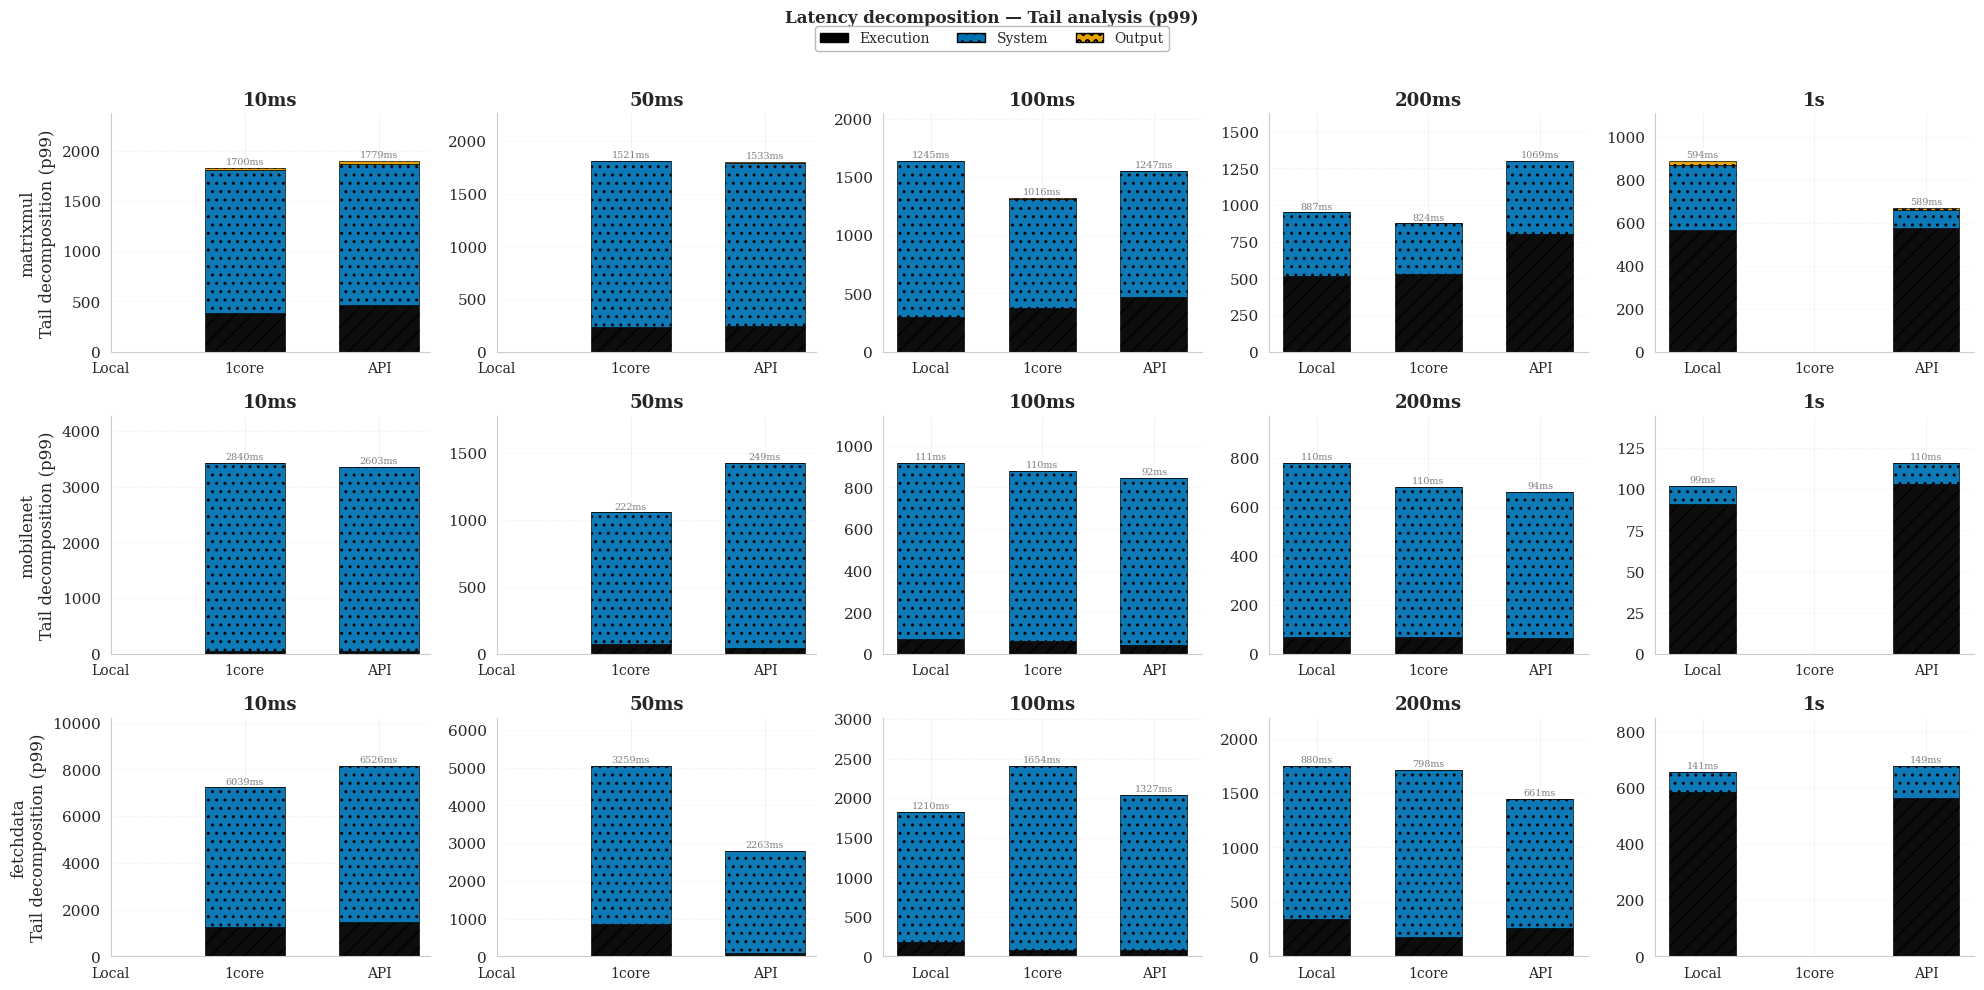

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────
# STYLE OSDI CLEAN
# ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

ARCHS = ["Local", "Local 1core", "Local APIserver"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: f"all_data_decomposed_{d}.csv" for d in DELAYS
    },
    "Local 1core": {
        d: f"all_data_decomposed_{d}_1core.csv" for d in DELAYS
    },
    "Local APIserver": {
        d: f"all_data_decomposed_{d}_apiserver_pinned.csv" for d in DELAYS
    },
}

FUNCTIONS = [
    "matrixmul",
    "mobilenet",
    "fetchdata"
]

REQ_TYPE = "warm"

STACK_COLS = [
    "execution_time_ms",
    "system_overhead_ms",
    "output_transfer_ms"
]

STACK_LABELS = ["Execution", "System", "Output"]

COLORS = ["#000000", "#0072B2", "#E69F00"]
HATCHES = ["//", "..", "oo"]

# ─────────────────────────────────────────────────────────────
# CHOOSE PERCENTILE HERE
# ─────────────────────────────────────────────────────────────
PERCENTILE_TO_PLOT = 99   # <-- change to 99 for tail

# ─────────────────────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────────────────────
def load(arch, delay, fn):

    path = FILES[arch][delay]

    if not os.path.exists(path):
        return None

    df = pd.read_csv(path)

    df = df[
        (df["status"] == 200) &
        (df["type"] == REQ_TYPE) &
        (df["function"] == fn)
    ].copy()

    if len(df) == 0:
        return None

    for c in STACK_COLS + ["latency_ms"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df.dropna(subset=["latency_ms"])

# ─────────────────────────────────────────────────────────────
# DECOMPOSITION
# ─────────────────────────────────────────────────────────────
def decompose(df, pct):

    thr = np.percentile(df["latency_ms"], pct)
    tail = df[df["latency_ms"] >= thr]

    if len(tail) == 0:
        return None

    return {
        "thr": thr,
        "vals": {c: tail[c].mean() for c in STACK_COLS}
    }

# ─────────────────────────────────────────────────────────────
# AVAILABLE DELAYS
# ─────────────────────────────────────────────────────────────
available = [
    d for d in DELAYS
    if any(load(a, d, FUNCTIONS[0]) is not None for a in ARCHS)
]

print("Delays:", available)

# ─────────────────────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    len(FUNCTIONS),
    len(available),
    figsize=(4 * len(available), 3.2 * len(FUNCTIONS)),
    sharey=False
)

if len(available) == 1:
    axes = axes.reshape(len(FUNCTIONS), 1)

x = np.arange(len(ARCHS))
bar_w = 0.6

for fi, fn in enumerate(FUNCTIONS):

    for di, delay in enumerate(available):

        ax = axes[fi][di]

        global_max = 0

        for ai, arch in enumerate(ARCHS):

            df = load(arch, delay, fn)
            if df is None:
                continue

            d = decompose(df, PERCENTILE_TO_PLOT)
            if d is None:
                continue

            bottom = 0

            for ci, col in enumerate(STACK_COLS):

                val = d["vals"][col]

                ax.bar(
                    ai,
                    val,
                    bottom=bottom,
                    width=bar_w,
                    color=COLORS[ci],
                    hatch=HATCHES[ci],
                    edgecolor="black",
                    linewidth=0.5,
                    alpha=0.95
                )

                bottom += val

            global_max = max(global_max, bottom)

            ax.text(
                ai,
                bottom + global_max * 0.02,
                f"{d['thr']:.0f}ms",
                ha="center",
                fontsize=7,
                color="gray"
            )

        ax.set_title(delay, fontweight="bold")

        if di == 0:
            ax.set_ylabel(
                f"{fn}\nTail decomposition (p{PERCENTILE_TO_PLOT})"
            )

        ax.set_xticks(x)
        ax.set_xticklabels(["Local", "1core", "API"])

        ax.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.75")

        ax.set_ylim(0, global_max * 1.25)

# ─────────────────────────────────────────────────────────────
# LEGEND
# ─────────────────────────────────────────────────────────────
handles = [
    Patch(facecolor=COLORS[i], hatch=HATCHES[i],
          edgecolor="black", label=STACK_LABELS[i])
    for i in range(3)
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
    framealpha=0.9
)

fig.suptitle(
    f"Latency decomposition — Tail analysis (p{PERCENTILE_TO_PLOT})",
    fontsize=12,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

# ─────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────
out = f"tail_decomposition_p{PERCENTILE_TO_PLOT}"

plt.savefig(out + ".pdf", dpi=300, bbox_inches="tight")
plt.savefig(out + ".png", dpi=300, bbox_inches="tight")

print(f"✓ Saved {out}.pdf/png")

✓ Saved client_view_p99.pdf/png


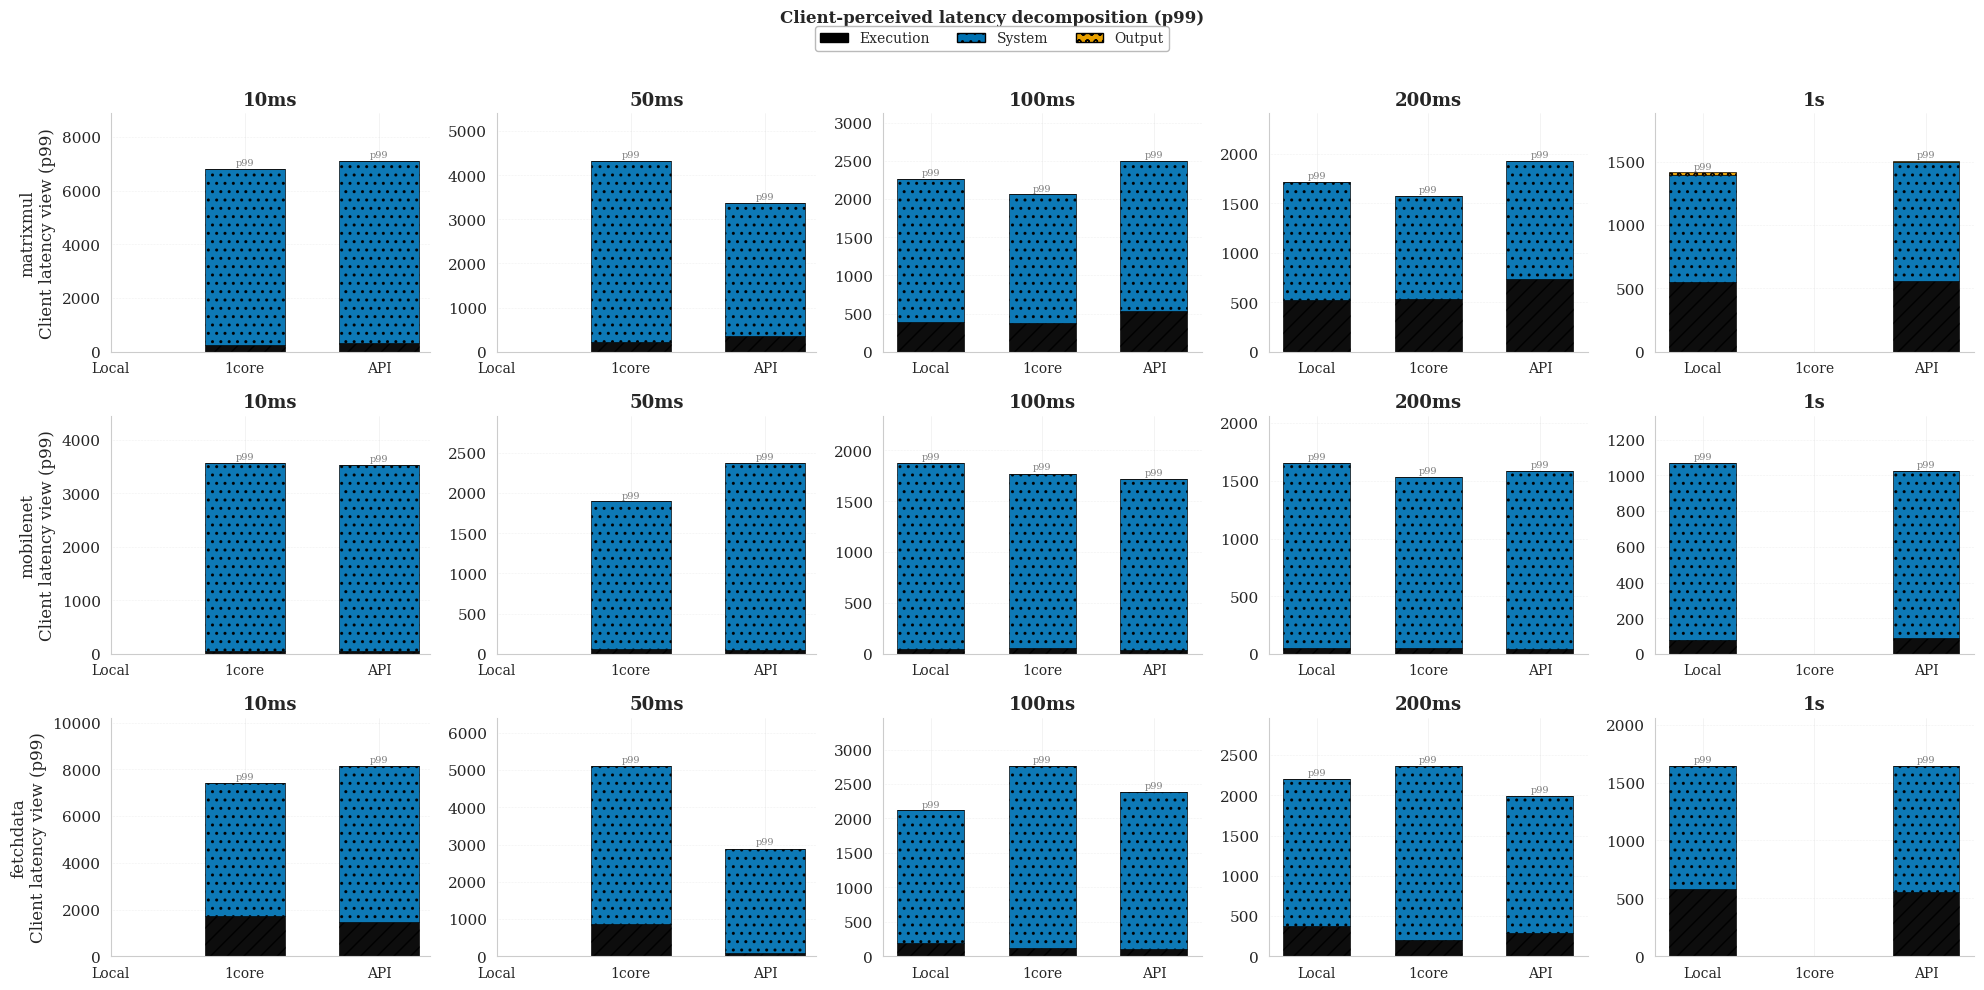

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────
# STYLE OSDI CLEAN
# ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

ARCHS = ["Local", "Local 1core", "Local APIserver"]

FILES = {
    "Local": {
        d: f"all_data_decomposed_{d}.csv" for d in DELAYS
    },
    "Local 1core": {
        d: f"all_data_decomposed_{d}_1core.csv" for d in DELAYS
    },
    "Local APIserver": {
        d: f"all_data_decomposed_{d}_apiserver_pinned.csv" for d in DELAYS
    },
}

FUNCTIONS = ["matrixmul", "mobilenet", "fetchdata"]

STACK_COLS = [
    "execution_time_ms",
    "system_overhead_ms",
    "output_transfer_ms"
]

STACK_LABELS = ["Execution", "System", "Output"]

COLORS = ["#000000", "#0072B2", "#E69F00"]
HATCHES = ["//", "..", "oo"]

PERCENTILE_TO_PLOT = 99

# ─────────────────────────────────────────────────────────────
# LOAD (NO TYPE FILTER → IMPORTANT)
# ─────────────────────────────────────────────────────────────
def load(arch, delay, fn):

    path = FILES[arch][delay]
    if not os.path.exists(path):
        return None

    df = pd.read_csv(path)

    df = df[
        (df["status"] == 200) &
        (df["function"] == fn)
    ].copy()

    if len(df) == 0:
        return None

    for c in STACK_COLS + ["latency_ms"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df.dropna(subset=["latency_ms"])

# ─────────────────────────────────────────────────────────────
# DECOMPOSITION
# ─────────────────────────────────────────────────────────────
def decompose(df, pct):

    thr = np.percentile(df["latency_ms"], pct)
    tail = df[df["latency_ms"] >= thr]

    if len(tail) == 0:
        return None

    return {
        "thr": thr,
        "vals": {c: tail[c].mean() for c in STACK_COLS}
    }

# ─────────────────────────────────────────────────────────────
available = [
    d for d in DELAYS
    if any(load(a, d, FUNCTIONS[0]) is not None for a in ARCHS)
]

fig, axes = plt.subplots(
    len(FUNCTIONS),
    len(available),
    figsize=(4 * len(available), 3.2 * len(FUNCTIONS)),
    sharey=False
)

if len(available) == 1:
    axes = axes.reshape(len(FUNCTIONS), 1)

x = np.arange(len(ARCHS))
bar_w = 0.6

for fi, fn in enumerate(FUNCTIONS):

    for di, delay in enumerate(available):

        ax = axes[fi][di]
        global_max = 0

        for ai, arch in enumerate(ARCHS):

            df = load(arch, delay, fn)
            if df is None:
                continue

            d = decompose(df, PERCENTILE_TO_PLOT)
            if d is None:
                continue

            bottom = 0

            for ci, col in enumerate(STACK_COLS):

                val = d["vals"][col]

                ax.bar(
                    ai,
                    val,
                    bottom=bottom,
                    width=bar_w,
                    color=COLORS[ci],
                    hatch=HATCHES[ci],
                    edgecolor="black",
                    linewidth=0.5,
                    alpha=0.95
                )

                bottom += val

            global_max = max(global_max, bottom)

            ax.text(
                ai,
                bottom + global_max * 0.02,
                f"p{PERCENTILE_TO_PLOT}",
                ha="center",
                fontsize=7,
                color="gray"
            )

        ax.set_title(delay, fontweight="bold")

        if di == 0:
            ax.set_ylabel(f"{fn}\nClient latency view (p{PERCENTILE_TO_PLOT})")

        ax.set_xticks(x)
        ax.set_xticklabels(["Local", "1core", "API"])

        ax.grid(True, axis="y", linestyle=":", linewidth=0.4, color="0.75")

        ax.set_ylim(0, global_max * 1.25)

# ─────────────────────────────────────────────────────────────
handles = [
    Patch(facecolor=COLORS[i], hatch=HATCHES[i],
          edgecolor="black", label=STACK_LABELS[i])
    for i in range(3)
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
    framealpha=0.9
)

fig.suptitle(
    f"Client-perceived latency decomposition (p{PERCENTILE_TO_PLOT})",
    fontsize=12,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

out = f"client_view_p{PERCENTILE_TO_PLOT}"
plt.savefig(out + ".pdf", dpi=300, bbox_inches="tight")
plt.savefig(out + ".png", dpi=300, bbox_inches="tight")

print(f"✓ Saved {out}.pdf/png")

In [51]:
for arch in ARCHS:
    print("RUNNING ARCH:", arch)

    df = load(arch, delay, fn)

    print("\nDEBUG LOAD", arch, delay, fn)

    if df is None:
        print("❌ DF is None (filtered out completely)")
        continue

    print("before filter:", len(df))

RUNNING ARCH: Local

DEBUG LOAD Local 1s fetchdata
before filter: 2170
RUNNING ARCH: Local 1core

DEBUG LOAD Local 1core 1s fetchdata
❌ DF is None (filtered out completely)
RUNNING ARCH: Local APIserver

DEBUG LOAD Local APIserver 1s fetchdata
before filter: 2170


Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [ABS] Local                               / 10ms p50=5671.9 p99=23311.8
  [ABS] Hybrid                              / 10ms p50=3753.6 p99=22710.5
  [ABS] Local 1core                         / 10ms p50=5617.8 p99=24205.7
  [ABS] Local (API server + pinned)         / 10ms p50=5408.4 p99=23419.6
  [ABS] Local                               / 50ms p50=16.1 p99=5854.6
  [ABS] Hybrid                              / 50ms p50=14.5 p99=4932.5
  [ABS] Local 1core                         / 50ms p50=13.7 p99=5354.3
  [ABS] Local (API server + pinned)         / 50ms p50=15.8 p99=5640.4
  [ABS] Local                               / 100ms p50=12.1 p99=4447.7
  [ABS] Hybrid                              / 100ms p50=13.4 p99=4893.2
  [ABS] Local 1core                         / 100ms p50=12.8 p99=4104.7
  [ABS] Local (API server + pinned)         / 100ms p50=13.1 p99=3828.2
  [ABS] Local                               / 200ms p50=11.9 p99=4143.2
 

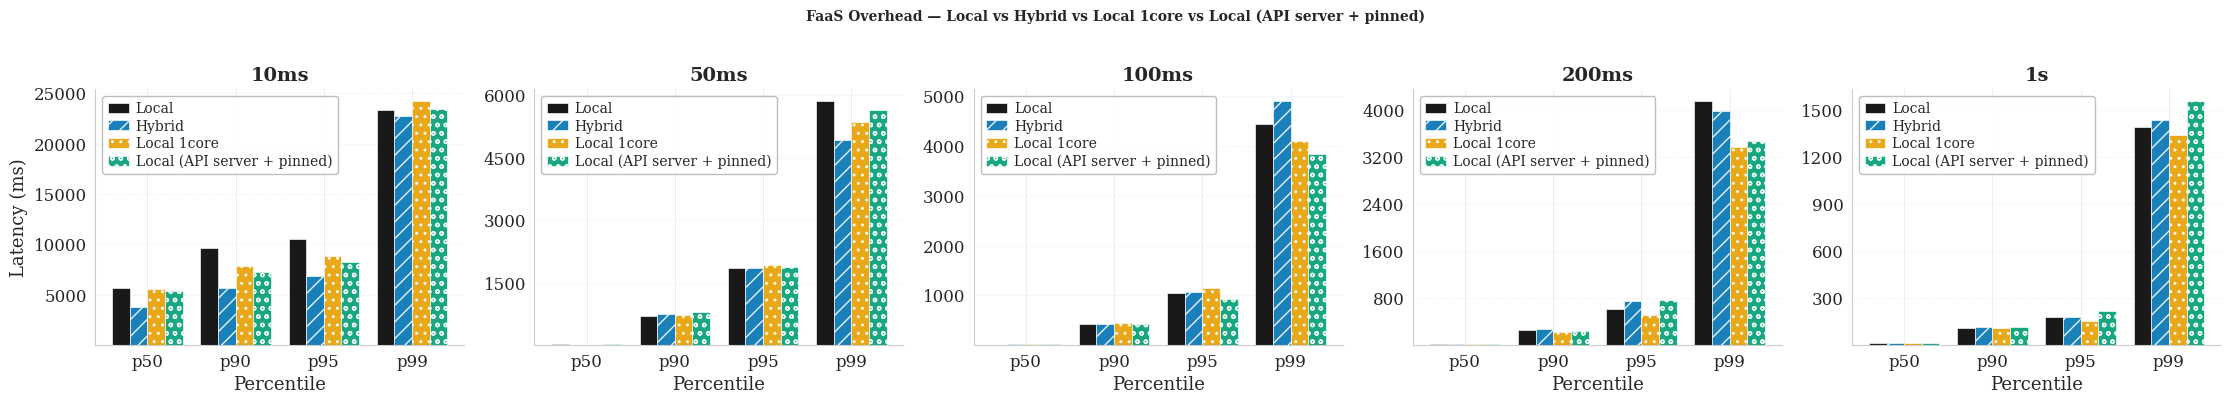

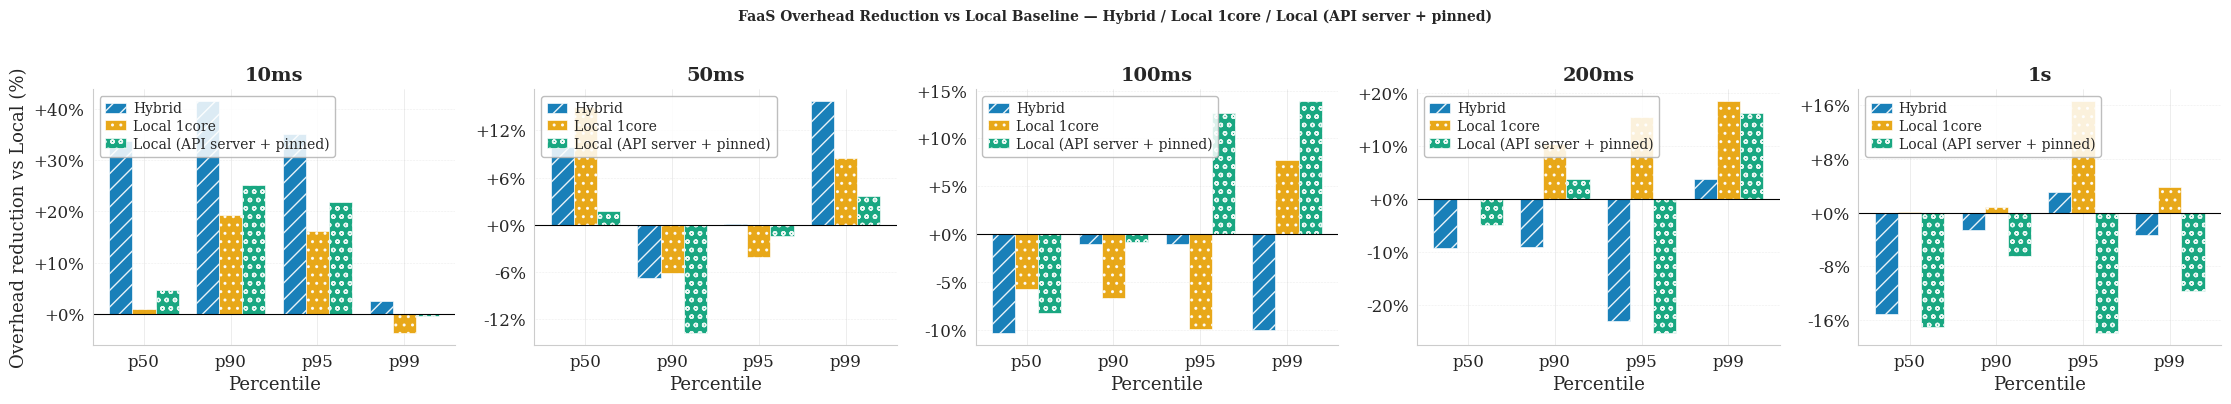

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    10,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.5,
    "grid.color":         "0.75",
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS  = ["#0072B2", "#E69F00", "#009E73"]
HATCHES = ["//",      "..",      "oo"]
LABELS  = ["Hybrid", "Local 1core", "Local (API server + pinned)"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS        = ["10ms", "50ms", "100ms", "200ms", "1s"]
PERCENTILES   = [50, 90, 95, 99]
PCTILE_LABELS = ["p50", "p90", "p95", "p99"]

DATA_DIR = "."

FILES = {
    "Local":           {d: os.path.join(DATA_DIR, f"all_data_{d}.csv")                  for d in DELAYS},
    "Hybrid":          {d: os.path.join(DATA_DIR, f"all_data_{d}_hybrid.csv")           for d in DELAYS},
    "Local1core":      {d: os.path.join(DATA_DIR, f"all_data_{d}_1core.csv")            for d in DELAYS},
    "APIserverPinned": {d: os.path.join(DATA_DIR, f"all_data_{d}_apiserver_pinned.csv") for d in DELAYS},
}

COMPARE_MODES = ["Hybrid", "Local1core", "APIserverPinned"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if not filepath or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    if "diff" not in df.columns:
        return None
    return df["diff"].dropna()

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    local_ok = os.path.exists(FILES["Local"][d])
    has_any  = any(os.path.exists(FILES[m][d]) for m in COMPARE_MODES)
    if local_ok and has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé.")

# ─── FIGURE 1 : overhead absolu (ms) ──────────────────────────────────
n         = len(available_delays)
n_modes   = len(COMPARE_MODES) + 1   # Local + 3
n_pctiles = len(PERCENTILES)
x         = np.arange(n_pctiles)
bar_width = 0.8 / n_modes

fig1, axes1 = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=False)
if n == 1:
    axes1 = [axes1]

all_modes  = ["Local"] + COMPARE_MODES
all_colors = ["#000000"] + COLORS
all_hatch  = [""] + HATCHES
all_labels = ["Local"] + LABELS

for c, delay in enumerate(available_delays):
    ax = axes1[c]
    for i, mode in enumerate(all_modes):
        data = load_series(FILES[mode][delay])
        if data is None:
            continue
        vals   = [np.percentile(data, p) for p in PERCENTILES]
        offset = (i - n_modes / 2 + 0.5) * bar_width
        ax.bar(x + offset, vals, width=bar_width,
               color=all_colors[i], hatch=all_hatch[i],
               label=all_labels[i], edgecolor="white",
               linewidth=0.5, alpha=0.9)
        print(f"  [ABS] {all_labels[i]:35s} / {delay} p50={vals[0]:.1f} p99={vals[3]:.1f}")

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Percentile")
    ax.set_xticks(x)
    ax.set_xticklabels(PCTILE_LABELS)
    if c == 0:
        ax.set_ylabel("Latency (ms)")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune='both'))
    ax.grid(True, axis='y', linestyle=':', linewidth=0.4, color='0.75')
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.legend(loc='upper left', handlelength=1.5, borderpad=0.4,
              labelspacing=0.25, handletextpad=0.5)

fig1.suptitle("FaaS Overhead — Local vs Hybrid vs Local 1core vs Local (API server + pinned)",
              fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
fig1.savefig("overhead_abs.pdf", dpi=300, bbox_inches="tight")
fig1.savefig("overhead_abs.png", dpi=300, bbox_inches="tight")
print("\n✓ Saved: overhead_abs.pdf / .png")

# ─── FIGURE 2 : gain relatif vs Local (%) ─────────────────────────────
# Message OSDI : "combien de % de gain par rapport à Local ?"
# Valeur positive = amélioration, négative = dégradation

fig2, axes2 = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=False)
if n == 1:
    axes2 = [axes2]

for c, delay in enumerate(available_delays):
    ax = axes2[c]

    base_data = load_series(FILES["Local"][delay])
    if base_data is None:
        continue
    base_vals = np.array([np.percentile(base_data, p) for p in PERCENTILES])

    n_cmp     = len(COMPARE_MODES)
    bar_width2 = 0.8 / n_cmp

    for i, mode in enumerate(COMPARE_MODES):
        data = load_series(FILES[mode][delay])
        if data is None:
            continue
        vals   = np.array([np.percentile(data, p) for p in PERCENTILES])
        # gain % : positif = moins d'overhead que Local
        gains  = (base_vals - vals) / base_vals * 100
        offset = (i - n_cmp / 2 + 0.5) * bar_width2

        bars = ax.bar(x + offset, gains, width=bar_width2,
                      color=COLORS[i], hatch=HATCHES[i],
                      label=LABELS[i], edgecolor="white",
                      linewidth=0.5, alpha=0.9)

        print(f"  [REL] {LABELS[i]:35s} / {delay} "
              f"p50={gains[0]:+.1f}%  p99={gains[3]:+.1f}%")

    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Percentile")
    ax.set_xticks(x)
    ax.set_xticklabels(PCTILE_LABELS)
    if c == 0:
        ax.set_ylabel("Overhead reduction vs Local (%)")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune='both'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
    ax.grid(True, axis='y', linestyle=':', linewidth=0.4, color='0.75')
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.legend(loc='upper left', handlelength=1.5, borderpad=0.4,
              labelspacing=0.25, handletextpad=0.5)

fig2.suptitle(
    "FaaS Overhead Reduction vs Local Baseline — Hybrid / Local 1core / Local (API server + pinned)",
    fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
fig2.savefig("overhead_relative.pdf", dpi=300, bbox_inches="tight")
fig2.savefig("overhead_relative.png", dpi=300, bbox_inches="tight")
print("✓ Saved: overhead_relative.pdf / .png")

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [OK]   Local / 10ms — 19992 samples, median=57.1ms, p99=3166.3ms
  [OK]   Hybrid / 10ms — 19984 samples, median=51.7ms, p99=3082.6ms
  [OK]   Local 1core / 10ms — 19991 samples, median=53.5ms, p99=3059.9ms
  [OK]   Local / 50ms — 20008 samples, median=23.2ms, p99=2723.0ms
  [OK]   Hybrid / 50ms — 20009 samples, median=23.2ms, p99=2708.8ms
  [OK]   Local 1core / 50ms — 20008 samples, median=23.4ms, p99=2740.3ms
  [OK]   Local / 100ms — 20008 samples, median=22.9ms, p99=2700.6ms
  [OK]   Hybrid / 100ms — 20009 samples, median=23.3ms, p99=2709.6ms
  [OK]   Local 1core / 100ms — 20009 samples, median=23.1ms, p99=2703.4ms
  [OK]   Local / 200ms — 20010 samples, median=23.3ms, p99=2697.4ms
  [OK]   Hybrid / 200ms — 20010 samples, median=23.4ms, p99=2707.5ms
  [OK]   Local 1core / 200ms — 20010 samples, median=23.2ms, p99=2700.0ms
  [OK]   Local / 1s — 20000 samples, median=23.5ms, p99=2711.9ms
  [OK]   Hybrid / 1s — 20000 samples, 

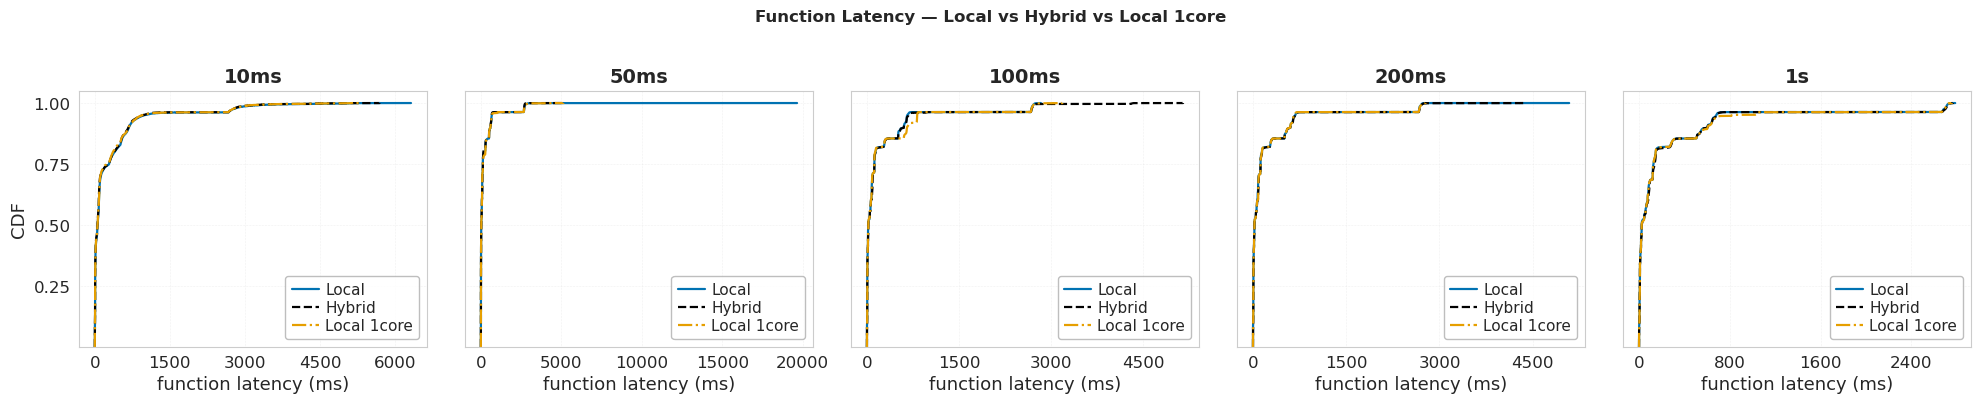

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS     = ["#0072B2", "#000000",  "#E69F00"]   # noir, bleu, orange
LINESTYLES = ["-",       "--",      "-."]
LABELS     = ["Local", "Hybrid", "Local 1core"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"all_data_{d}.csv") for d in DELAYS
    },
    "Hybrid": {
        d: os.path.join(DATA_DIR, f"all_data_{d}_hybrid.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"all_data_{d}_1core.csv") for d in DELAYS
    },
}

MODES = ["Local", "Hybrid", "Local 1core"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["execution_time_sec"].dropna()

# ─── STYLE AXES ───────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    has_any = any(os.path.exists(FILES[m][d]) for m in MODES)
    if has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé — vérifiez DATA_DIR et les noms de fichiers.")

# ─── FIGURE ───────────────────────────────────────────────────────────
n = len(available_delays)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)
        if data is None:
            print(f"  [SKIP] {mode} / {delay} — file not found")
            continue

        print(f"  [OK]   {mode} / {delay} — {len(data)} samples, median={data.median():.1f}ms, p99={data.quantile(0.99):.1f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=LABELS[i],
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("function latency (ms)")

    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(
        loc='lower right',
        handlelength=1.8,
        borderpad=0.4,
        labelspacing=0.2,
        handletextpad=0.4,
    )

    style_ax(ax)

# ─── TITRE ────────────────────────────────────────────────────────────
fig.suptitle(
    "Function Latency — Local vs Hybrid vs Local 1core",
    fontsize=12,
    fontweight='bold',
    y=1.01,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "func_ecdf_overlay.pdf"
out_png = "func_ecdf_overlay.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")